In [1]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit as qc
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram, array_to_latex
from qiskit.quantum_info import Statevector, Operator
import numpy as np

In [3]:
def histogramRep(circuit: qc, shots: int = 1024):
    qch = circuit.copy()            
    qch.measure_all()                 

    sim = AerSimulator()
    tqc = transpile(qch, sim)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    fig = plot_histogram(counts)      
    plt.show()
    return fig

Enter no of qbits: 3
Enter the search key: 7


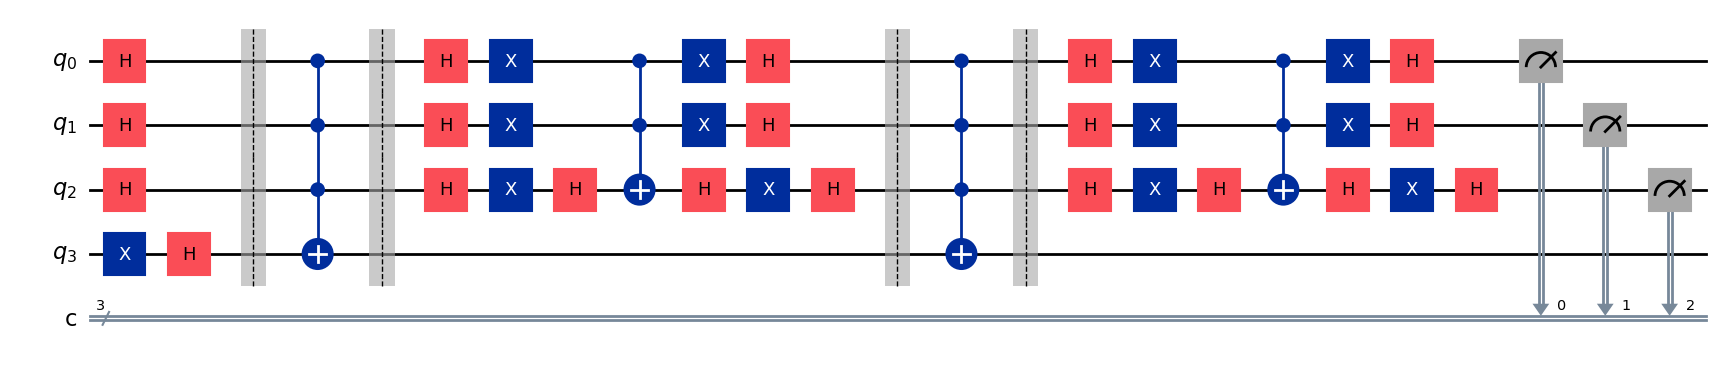

In [5]:
n = int(input("Enter no of qbits:"))
w = int(input("Enter the search key:"))
wbin = format(w, f'0{n}b')[::-1] # Reverse for Qiskit endianness

# n data qubits + 1 ancilla qubit
groverCircuit = qc(n + 1,n)

#  INITIALIZATION 
groverCircuit.x(n) 
for i in range(n + 1):
    groverCircuit.h(i) 

# CALCULATE ITERATIONS 
iterations = int(np.floor(np.pi/4 * np.sqrt(2**n)))

for _ in range(iterations):
    groverCircuit.barrier()
    
    # ORACLE
    for j in range(n):
        if wbin[j] == '0':
            groverCircuit.x(j)
            
    groverCircuit.mcx(list(range(n)), n) 
    
    for j in range(n):
        if wbin[j] == '0':
            groverCircuit.x(j)
            
    groverCircuit.barrier()

    # DIFFUSER (Inversion about Mean) 
    for i in range(n):
        groverCircuit.h(i)
        groverCircuit.x(i)
        
    # Multi-controlled Z logic for diffuser
    groverCircuit.h(n-1)
    groverCircuit.mcx(list(range(n-1)), n-1)
    groverCircuit.h(n-1)
    
    for i in range(n):
        groverCircuit.x(i)
        groverCircuit.h(i)

# Measurement
for i in range(n):
    groverCircuit.measure(i,i)

groverCircuit.draw('mpl')


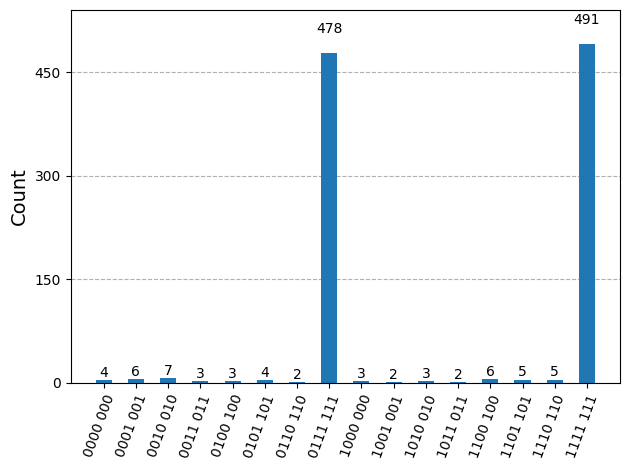

In [7]:
histogramRep(groverCircuit)